# ✍️ Digit Recognizer — Computer Vision with MNIST

---
Classify handwritten digits (0–9) from the [Kaggle Digit Recognizer](https://www.kaggle.com/competitions/digit-recognizer) dataset.
**Two-phase workflow**: select the best model on a validation split → retrain it on the full dataset → predict the test set for Kaggle.

## 🎯 Goals
- Compare classic baselines (Logistic Regression, Gaussian NB, Decision Tree) against an **MLP** (multi-layer neural network).
- Understand why scaling pixels to `[0, 1]` helps the model converge better.
- Select the model by **validation accuracy**, then retrain on all 42,000 samples.
- Generate `submission.csv` for Kaggle and save artifacts + charts for the README.

In [1]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

RANDOM_STATE = 42
TEST_SIZE = 0.2

DATA_DIR = Path("data")
ASSETS = Path("docs/assets"); ASSETS.mkdir(parents=True, exist_ok=True)
OUTPUTS = Path("outputs"); OUTPUTS.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
np.random.seed(RANDOM_STATE)
print("Setup OK")

Setup OK


## 🔹 Step 1: Load the data

`train.csv` has a `label` column (0–9) plus 784 pixel columns (28×28 image). `test.csv` has pixels only — labels need to be predicted.

In [2]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")

y = train_df["label"].to_numpy()
X = train_df.drop(columns=["label"]).to_numpy()
X_test = test_df.to_numpy()

print(f"Train: {X.shape}  |  labels: {y.shape}")
print(f"Test:  {X_test.shape}")
train_df.head()

Train: (42000, 784)  |  labels: (42000,)
Test:  (28000, 784)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 🔹 Step 2: EDA — sample images & class distribution

Look at a few sample digits and check the distribution across the 10 classes (MNIST is fairly balanced).

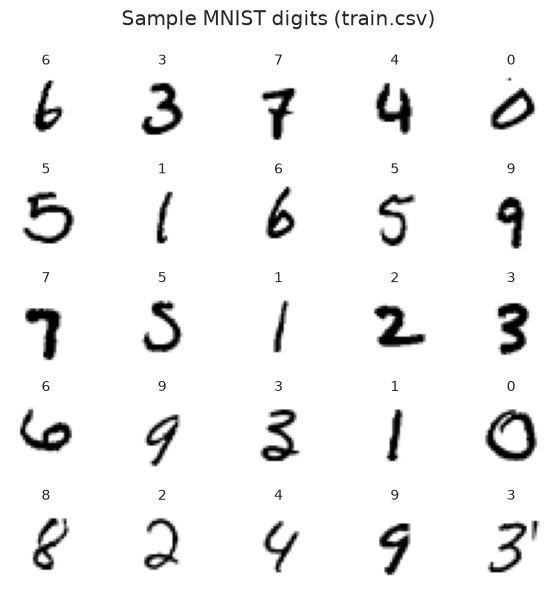

In [3]:
rng = np.random.default_rng(RANDOM_STATE)
idx = rng.choice(len(y), size=25, replace=False)

fig, axes = plt.subplots(5, 5, figsize=(6, 6))
for ax, i in zip(axes.ravel(), idx):
    ax.imshow(X[i].reshape(28, 28), cmap="gray_r", vmin=0, vmax=255)
    ax.set_title(str(y[i]), fontsize=10)
    ax.axis("off")
fig.suptitle("Sample MNIST digits (train.csv)", y=0.98)
fig.tight_layout()
fig.savefig(ASSETS / "sample_digits.png", dpi=120, bbox_inches="tight")
plt.show()

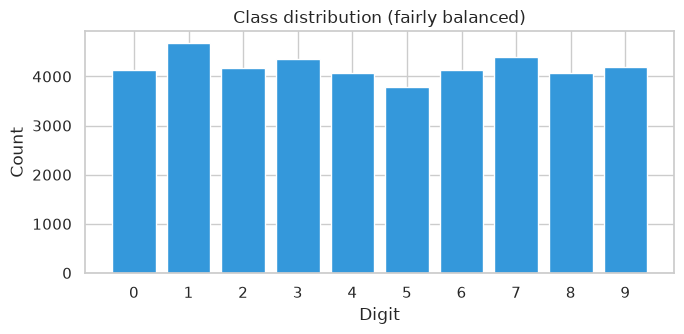

min/max per class: 3795 / 4684


In [4]:
counts = pd.Series(y).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(counts.index.astype(str), counts.values, color="#3498db")
ax.set_xlabel("Digit"); ax.set_ylabel("Count")
ax.set_title("Class distribution (fairly balanced)")
fig.tight_layout()
plt.show()
print("min/max per class:", counts.min(), "/", counts.max())

## 🔹 Step 3: Scale pixels & split train/validation

Pixels `0–255` are divided by `255` to land in `[0, 1]` (helps the MLP converge faster and more stably). An 80/20 split with `stratify` preserves the class ratio across all 10 digits.

In [5]:
X_scaled = X.astype(np.float32) / 255.0
X_test_scaled = X_test.astype(np.float32) / 255.0

X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape}  |  Val: {X_val.shape}")

Train: (33600, 784)  |  Val: (8400, 784)


## 🔹 Step 4 (Phase 1): Model selection on validation

Train 4 models and compare validation accuracy:

| Model | Note |
|---|---|
| Logistic Regression | linear, strong baseline |
| Gaussian Naive Bayes | assumes independent pixels → weak on images |
| Decision Tree | non-linear, prone to overfitting |
| **MLP (256→128)** | neural network, expected to win |

In [6]:
def build_models():
    return {
        "logreg": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        "gnb": GaussianNB(),
        "dt": DecisionTreeClassifier(max_depth=20, random_state=RANDOM_STATE),
        "mlp": MLPClassifier(
            hidden_layer_sizes=(256, 128), activation="relu", solver="adam",
            alpha=1e-4, batch_size=256, learning_rate_init=1e-3, max_iter=50,
            early_stopping=True, validation_fraction=0.1, random_state=RANDOM_STATE,
        ),
    }

scores = {}
for name, model in build_models().items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_val, model.predict(X_val))
    scores[name] = acc
    print(f"{name:8s} val accuracy = {acc:.4f}")

leaderboard = (pd.DataFrame({"model": list(scores), "accuracy": list(scores.values())})
               .sort_values("accuracy", ascending=False).reset_index(drop=True))
best_model_name = leaderboard.iloc[0]["model"]
print(f"\nBest model: {best_model_name} ({scores[best_model_name]:.4f})")
leaderboard

logreg   val accuracy = 0.9135


gnb      val accuracy = 0.5620


dt       val accuracy = 0.8644


mlp      val accuracy = 0.9752

Best model: mlp (0.9752)


,model,accuracy
0,mlp,0.975238
1,logreg,0.913452
2,dt,0.864405
3,gnb,0.562024


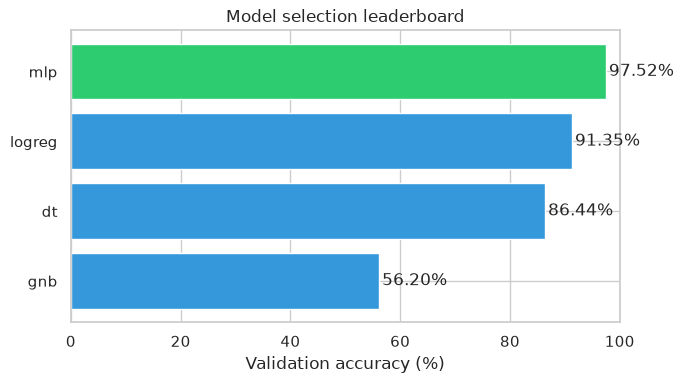

In [7]:
lb = leaderboard.sort_values("accuracy")
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#2ecc71" if v == lb["accuracy"].max() else "#3498db" for v in lb["accuracy"]]
bars = ax.barh(lb["model"], lb["accuracy"] * 100, color=colors)
ax.set_xlim(0, 100); ax.set_xlabel("Validation accuracy (%)")
ax.set_title("Model selection leaderboard")
for b, v in zip(bars, lb["accuracy"]):
    ax.text(b.get_width() + 0.5, b.get_y() + b.get_height() / 2, f"{v*100:.2f}%", va="center")
fig.tight_layout()
fig.savefig(ASSETS / "leaderboard.png", dpi=120, bbox_inches="tight")
plt.show()

## 🔹 Step 5: Analyze the best model on validation

The confusion matrix + classification report reveal which digits get confused most often (e.g. 4↔9, 3↔5).

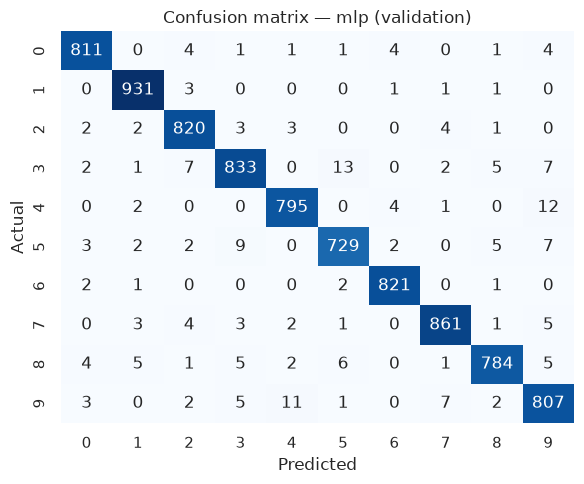

              precision    recall  f1-score   support

           0      0.981     0.981     0.981       827
           1      0.983     0.994     0.988       937
           2      0.973     0.982     0.977       835
           3      0.970     0.957     0.964       870
           4      0.977     0.977     0.977       814
           5      0.968     0.960     0.964       759
           6      0.987     0.993     0.990       827
           7      0.982     0.978     0.980       880
           8      0.979     0.964     0.971       813
           9      0.953     0.963     0.958       838

    accuracy                          0.975      8400
   macro avg      0.975     0.975     0.975      8400
weighted avg      0.975     0.975     0.975      8400



In [8]:
best_val_model = build_models()[best_model_name]
best_val_model.fit(X_train, y_train)
y_val_pred = best_val_model.predict(X_val)

cm = confusion_matrix(y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion matrix — {best_model_name} (validation)")
fig.tight_layout()
fig.savefig(ASSETS / "confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

print(classification_report(y_val, y_val_pred, digits=3))

## 🔹 Step 6 (Phase 2): Retrain on the full dataset & predict on test

Retrain the best model on **all 42,000 samples** (no more validation split), then predict on `test.csv` for the Kaggle submission.

In [9]:
final_model = build_models()[best_model_name]
final_model.fit(X_scaled, y)  # full training set

test_pred = final_model.predict(X_test_scaled)
submission = pd.DataFrame({
    "ImageId": np.arange(1, len(test_pred) + 1),
    "Label": test_pred.astype(int),
})
submission.to_csv(OUTPUTS / "submission.csv", index=False)
joblib.dump(final_model, OUTPUTS / "model.joblib")
print(f"Retrained {best_model_name} on {len(y):,} rows")
print(f"Wrote {len(submission):,} predictions -> outputs/submission.csv")
print("Saved model -> outputs/model.joblib")
submission.head()

Retrained mlp on 42,000 rows
Wrote 28,000 predictions -> outputs/submission.csv
Saved model -> outputs/model.joblib


,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3


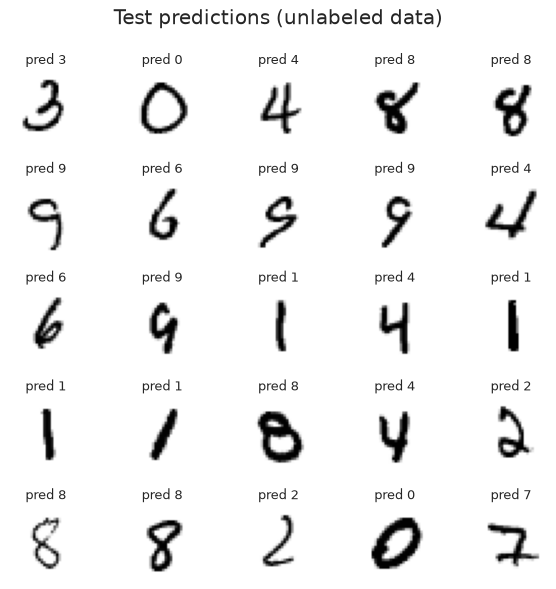

In [10]:
# Preview predictions on unseen test images
idx = rng.choice(len(test_pred), size=25, replace=False)
fig, axes = plt.subplots(5, 5, figsize=(6, 6))
for ax, i in zip(axes.ravel(), idx):
    ax.imshow(X_test[i].reshape(28, 28), cmap="gray_r", vmin=0, vmax=255)
    ax.set_title(f"pred {test_pred[i]}", fontsize=9)
    ax.axis("off")
fig.suptitle("Test predictions (unlabeled data)", y=0.98)
fig.tight_layout()
fig.savefig(ASSETS / "predictions_grid.png", dpi=120, bbox_inches="tight")
plt.show()

## 🔹 Step 7: Save the results summary

Write `docs/assets/run_summary.json` so the README can display the latest numbers.

In [11]:
summary = {
    "best_model": best_model_name,
    "validation_accuracy": float(scores[best_model_name]),
    "model_scores": {k: float(v) for k, v in scores.items()},
    "n_train_full": int(len(y)),
    "n_val": int(len(y_val)),
    "test_predictions": int(len(test_pred)),
    "model_artifact": "outputs/model.joblib",
}
with open(ASSETS / "run_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2))

{
  "best_model": "mlp",
  "validation_accuracy": 0.9752380952380952,
  "model_scores": {
    "logreg": 0.9134523809523809,
    "gnb": 0.5620238095238095,
    "dt": 0.8644047619047619,
    "mlp": 0.9752380952380952
  },
  "n_train_full": 42000,
  "n_val": 8400,
  "test_predictions": 28000,
  "model_artifact": "outputs/model.joblib"
}


## ✅ Conclusion

- **MLP clearly outperforms** the classic baselines (~97.5% vs LogReg ~91%, DT ~86%, GNB ~56%).
- **Gaussian NB is weak** because it assumes independent pixels — false for image data.
- Scaling pixels to `[0, 1]` plus a two-phase workflow (select → retrain on full data) keeps the pipeline compact and reproducible.

**Possible next steps:** a CNN (PyTorch/Keras) to push accuracy above 99%, data augmentation, or PCA for dimensionality reduction before training the baselines.